In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, accuracy_score, classification_report, f1_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout, BatchNormalization

2025-02-26 18:14:32.644888: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-26 18:14:32.696950: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-26 18:14:33.775981: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
df = pd.read_excel("netflix_data.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6403 entries, 0 to 6402
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   N_id             6403 non-null   int64  
 1   Title            6403 non-null   object 
 2   Main Genre       6403 non-null   object 
 3   Sub Genres       6403 non-null   object 
 4   Release Year     6402 non-null   float64
 5   Maturity Rating  6403 non-null   object 
 6   Original Audio   3767 non-null   object 
 7   Recommendations  6392 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 400.3+ KB


In [4]:
df.describe()

,N_id,Release Year
count,6.403000e+03,6402.000000
mean,7.971379e+07,2019.077320
std,7.159805e+06,6.094716
min,2.153090e+05,1962.000000
25%,8.022148e+07,2018.000000
50%,8.122164e+07,2021.000000
75%,8.151819e+07,2022.000000
max,8.199405e+07,2025.000000


In [5]:
df.isnull().sum()

N_id                  0
Title                 0
Main Genre            0
Sub Genres            0
Release Year          1
Maturity Rating       0
Original Audio     2636
Recommendations      11
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
label_encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

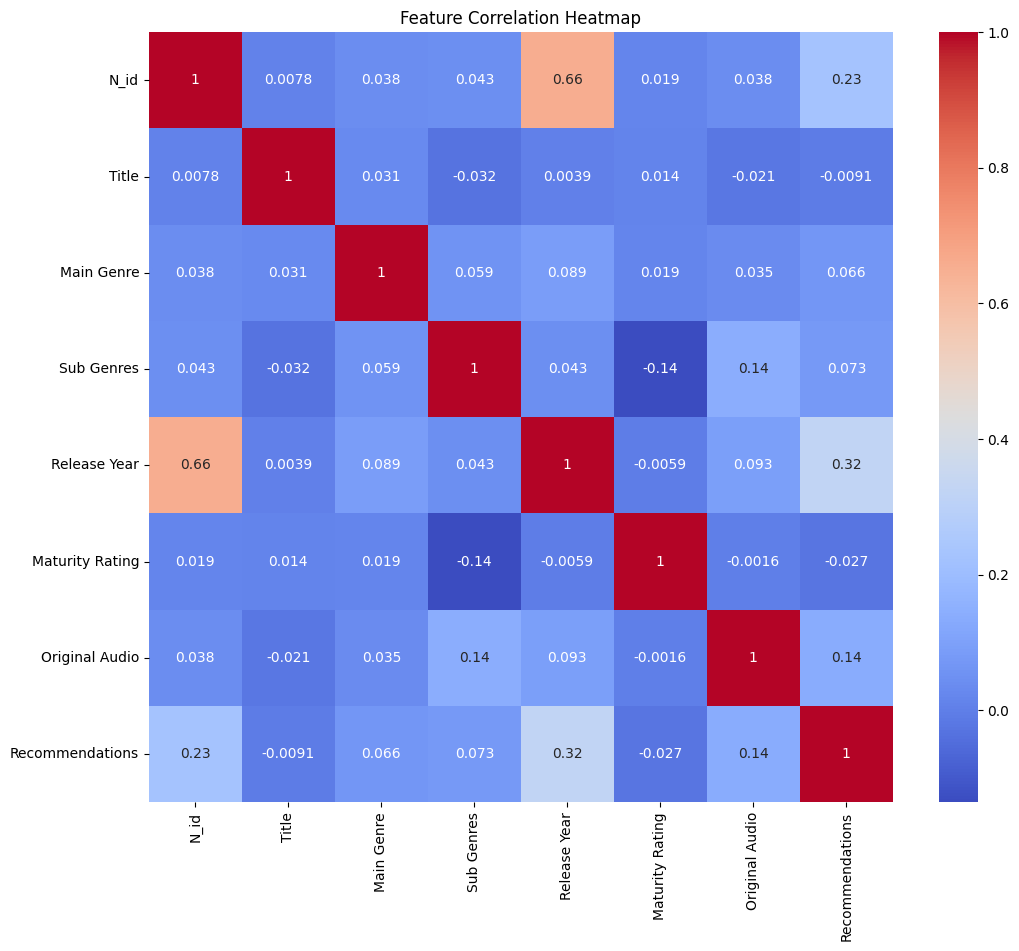

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
X = df.drop(columns=["Maturity Rating"])
y = df["Maturity Rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=537)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_split=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
}

regression_results = []
for name, model in regressors.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    end = time.time()
    r2 = r2_score(y_test, y_pred)
    regression_results.append([name, r2, end - start])

regression_df = pd.DataFrame(regression_results, columns=['Model', 'R2 Score', 'Time'])

In [11]:
regression_df

,Model,R2 Score,Time
0,Linear Regression,0.024754,0.003342
1,Ridge,0.024752,0.002714
2,Lasso,0.014620,0.004820
3,ElasticNet,0.021995,0.001921
4,Decision Tree,-0.195774,0.020219
5,Random Forest,0.143972,1.271461
6,Gradient Boosting,0.156302,1.040466


In [13]:
classifiers = {
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC()
}

In [16]:
optimized_classifiers = {}
for name, model in classifiers.items():
    param_grid = {}
    if name == "Random Forest":
        param_grid = {
            "n_estimators": [50, 100, 200, 300],
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    elif name == "SVM":
        param_grid = {
            "C": [0.1, 1, 10],
            "gamma": [0.01, 0.1, 1],
            "kernel": ['rbf', 'linear']
        }
    
    if param_grid:
        gscv = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
        gscv.fit(X_train, y_train)
        best_params = gscv.best_params_
        optimized_classifiers[name] = model.set_params(**best_params)
    else:
        optimized_classifiers[name] = model


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, min_samples_leaf=1,

In [17]:
optimized_classification_results = []
for name, model in optimized_classifiers.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    end = time.time()
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    optimized_classification_results.append([name, acc, f1, end - start])

optimized_classification_df = pd.DataFrame(optimized_classification_results, columns=['Model', 'Accuracy', 'F1 Score', 'Time'])

In [18]:
optimized_classification_df

,Model,Accuracy,F1 Score,Time
0,Random Forest,0.489362,0.493208,0.382390
1,SVC,0.384309,0.361866,0.633924


In [19]:
results = []

In [20]:
model_ann = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1], )),
    BatchNormalization(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
model_ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
start = time.time()
history_ann = model_ann.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=1)
end = time.time()
ann_acc = history_ann.history["val_accuracy"][-1]
results.append(["ANN", ann_acc, end -start])

Epoch 1/20
94/94 [==============================] - 2s 5ms/step - loss: -25.6471 - accuracy: 0.0276 - val_loss: -32.3171 - val_accuracy: 0.0359
Epoch 2/20
94/94 [==============================] - 0s 3ms/step - loss: -689.3307 - accuracy: 0.0269 - val_loss: -1301.3521 - val_accuracy: 0.0359
Epoch 3/20
94/94 [==============================] - 0s 3ms/step - loss: -7922.2148 - accuracy: 0.0269 - val_loss: -15311.9785 - val_accuracy: 0.0359
Epoch 4/20
94/94 [==============================] - 0s 3ms/step - loss: -38653.9531 - accuracy: 0.0269 - val_loss: -70000.3906 - val_accuracy: 0.0359
Epoch 5/20
94/94 [==============================] - 0s 3ms/step - loss: -114076.1172 - accuracy: 0.0269 - val_loss: -192406.8125 - val_accuracy: 0.0359
Epoch 6/20
94/94 [==============================] - 0s 4ms/step - loss: -265072.2500 - accuracy: 0.0269 - val_loss: -414575.9688 - val_accuracy: 0.0359
Epoch 7/20
94/94 [==============================] - 0s 3ms/step - loss: -525962.8750 - accuracy: 0.0269 - 

In [21]:
model_rnn = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)),
    SimpleRNN(30, activation='relu', return_sequences=False),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
start = time.time()
history_rnn = model_rnn.fit(X_train.reshape(-1, X_train.shape[1], 1), y_train, epochs=20, validation_data=(X_test.reshape(-1, X_test.shape[1], 1), y_test), verbose=1)
end = time.time()
rnn_acc = history_rnn.history['val_accuracy'][-1]
results.append(["RNN", rnn_acc, end - start])

Epoch 1/20
94/94 [==============================] - 3s 8ms/step - loss: -39605.4766 - accuracy: 0.0269 - val_loss: -537206.1875 - val_accuracy: 0.0359
Epoch 2/20
94/94 [==============================] - 0s 5ms/step - loss: -494638176.0000 - accuracy: 0.0269 - val_loss: -3462122240.0000 - val_accuracy: 0.0359
Epoch 3/20
94/94 [==============================] - 0s 5ms/step - loss: -125903675392.0000 - accuracy: 0.0269 - val_loss: -535714889728.0000 - val_accuracy: 0.0359
Epoch 4/20
94/94 [==============================] - 0s 5ms/step - loss: -5123017277440.0000 - accuracy: 0.0269 - val_loss: -16221033463808.0000 - val_accuracy: 0.0359
Epoch 5/20
94/94 [==============================] - 0s 5ms/step - loss: -78946347515904.0000 - accuracy: 0.0269 - val_loss: -201485321240576.0000 - val_accuracy: 0.0359
Epoch 6/20
94/94 [==============================] - 1s 7ms/step - loss: -706918129598464.0000 - accuracy: 0.0269 - val_loss: -1514014358110208.0000 - val_accuracy: 0.0359
Epoch 7/20
94/94 [=

In [22]:
model_gru = Sequential([
    GRU(50, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)),
    GRU(30, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
start = time.time()
history_gru = model_gru.fit(X_train.reshape(-1, X_train.shape[1], 1), y_train, epochs=20, validation_data=(X_test.reshape(-1, X_test.shape[1], 1), y_test), verbose=1)
end = time.time()
gru_acc = history_gru.history['val_accuracy'][-1]
results.append(["GRU", gru_acc, end - start])

Epoch 1/20
94/94 [==============================] - 4s 11ms/step - loss: -4039.1995 - accuracy: 0.0299 - val_loss: -75703.4453 - val_accuracy: 0.0359
Epoch 2/20
94/94 [==============================] - 1s 7ms/step - loss: -261775456.0000 - accuracy: 0.0269 - val_loss: -1989031552.0000 - val_accuracy: 0.0359
Epoch 3/20
94/94 [==============================] - 1s 8ms/step - loss: -97223835648.0000 - accuracy: 0.0269 - val_loss: -434359205888.0000 - val_accuracy: 0.0359
Epoch 4/20
94/94 [==============================] - 1s 8ms/step - loss: -4730283622400.0000 - accuracy: 0.0269 - val_loss: -15809994817536.0000 - val_accuracy: 0.0359
Epoch 5/20
94/94 [==============================] - 1s 7ms/step - loss: -81699086008320.0000 - accuracy: 0.0269 - val_loss: -214951067123712.0000 - val_accuracy: 0.0359
Epoch 6/20
94/94 [==============================] - 1s 8ms/step - loss: -761945787465728.0000 - accuracy: 0.0269 - val_loss: -1654338053210112.0000 - val_accuracy: 0.0359
Epoch 7/20
94/94 [===

In [23]:
dl_results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Time'])

In [24]:
dl_results_df

,Model,Accuracy,Time
0,ANN,0.035904,6.871524
1,RNN,0.035904,11.822407
2,GRU,0.035904,23.416641


In [25]:
def visualize_results(df, title, ylabel):
    plt.figure(figsize=(10, 5))
    plt.bar(df["Model"], df[ylabel], color="skyblue", alpha=0.7)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

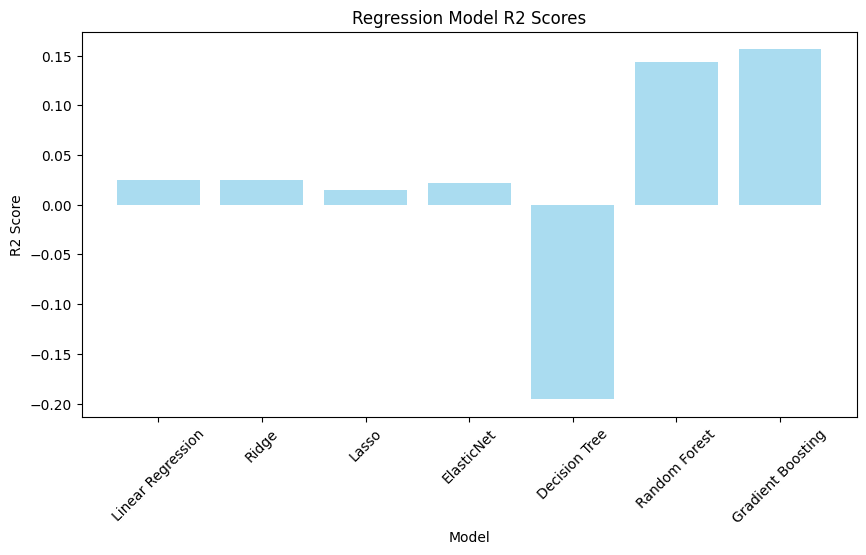

In [26]:
visualize_results(regression_df, "Regression Model R2 Scores", "R2 Score")

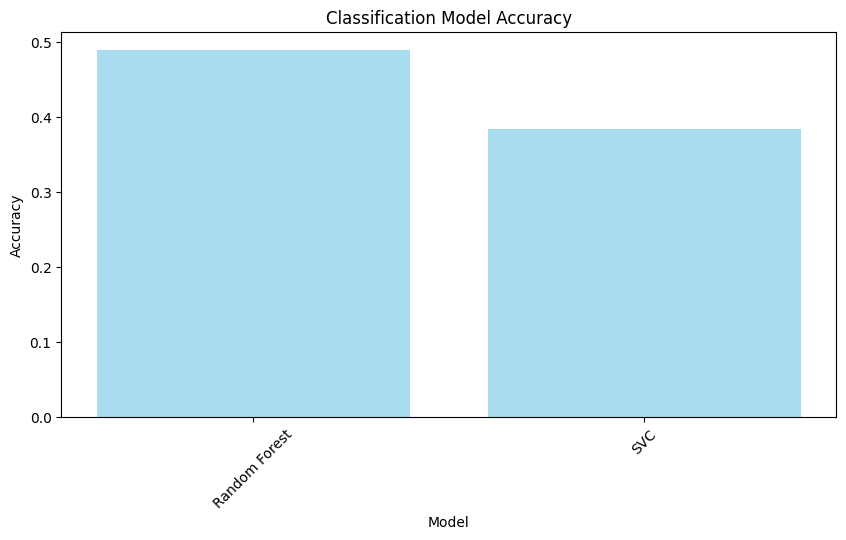

In [27]:
visualize_results(optimized_classification_df, "Classification Model Accuracy", "Accuracy")

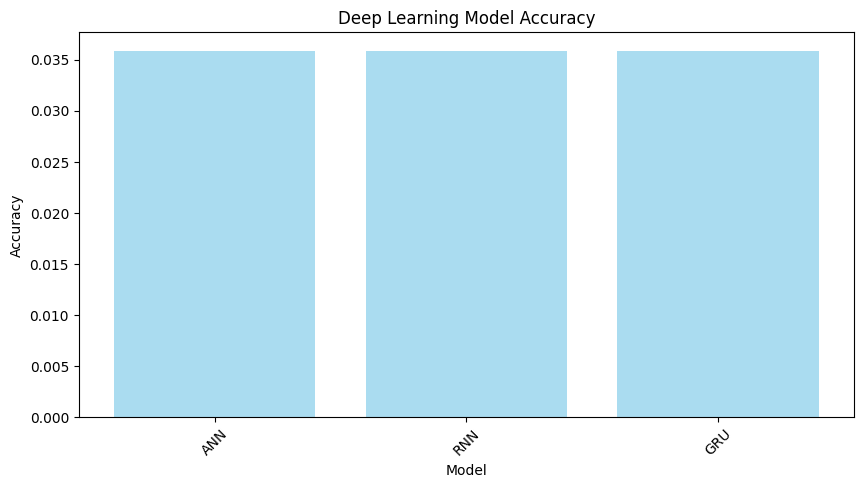

In [29]:
visualize_results(dl_results_df, "Deep Learning Model Accuracy", "Accuracy")